# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [22]:
df = pd.read_csv('Aviation_Accidents_cleaned.csv', low_memory=False)
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total_Passengers,Severe_Injury_Rate,Is_Destroyed,Plane_Type
0,20001214X42095,Accident,SEA83LA036,1983-01-01,"NEWPORT, OR",United States,NaN,NaN,ONP,NEWPORT MUNICIPAL,...,1.0,3.0,VMC,Approach,Probable Cause,NaN,4.0,0.0,0,CESSNA - 182P
1,20001214X42067,Accident,MKC83LA056,1983-01-01,"WOODBINE, IA",United States,NaN,NaN,3YR,MUNICIPAL,...,0.0,2.0,VMC,Landing,Probable Cause,NaN,2.0,0.0,0,CESSNA - 182RG
2,20001214X42063,Accident,MKC83LA050,1983-01-01,"MARYVILLE, MO",United States,NaN,NaN,78Y,RANKIN,...,0.0,1.0,VMC,Takeoff,Probable Cause,NaN,1.0,0.0,0,CESSNA - 182P
3,20001214X42018,Accident,LAX83FUG11,1983-01-01,"UPLAND, CA",United States,NaN,NaN,CCB,CABLE,...,2.0,0.0,VMC,Approach,Probable Cause,NaN,2.0,0.0,0,PIPER - PA-28R-200
4,20001214X41951,Accident,CHI83LA074,1983-01-01,"SPRINGBROOK, WI",United States,NaN,NaN,NaN,SPRINGBROOK,...,0.0,2.0,VMC,Landing,Probable Cause,NaN,2.0,0.0,0,CESSNA - 140


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [23]:
if 'Number.of.Seats' not in df.columns:
    df['Total.Occupants'] = (
        df['Total.Fatal.Injuries'].fillna(0) + 
        df['Total.Serious.Injuries'].fillna(0) + 
        df['Total.Minor.Injuries'].fillna(0) + 
        df['Total.Uninjured'].fillna(0)
    )
    seat_col = 'Total.Occupants'
else:
    seat_col = 'Number.of.Seats'

# Separate the plane types based on the threshold of 20 passengers/seats
small_planes = df[df[seat_col] <= 20].copy()
large_planes = df[df[seat_col] > 20].copy()

In [24]:
# Helper function to compute safety metrics for a given dataframe
def get_safety_metrics(dataframe, group_cols):
    metrics = dataframe.groupby(group_cols).agg(
        Total_Accidents=('Event.Id', 'count'), # or whatever your primary key is
        Total_Fatalities=('Total.Fatal.Injuries', 'sum'),
        Avg_Fatalities=('Total.Fatal.Injuries', 'mean')
    ).reset_index()
    
    # Filter for makes/models with a meaningful history (e.g., more than 5 accidents)
    metrics = metrics[metrics['Total_Accidents'] >= 5]
    
    # Sort by the safest (lowest average fatalities) and highest volume
    return metrics.sort_values(by=['Total_Accidents', 'Avg_Fatalities'], ascending=[False, True])

In [25]:
# Analyze Small Airplanes
small_make_model_safety = get_safety_metrics(small_planes, ['Make', 'Model'])

# Analyze Large Airplanes
large_make_model_safety = get_safety_metrics(large_planes, ['Make', 'Model'])

In [26]:
small_make_model_safety.head(10)

,Make,Model,Total_Accidents,Total_Fatalities,Avg_Fatalities
2137,CESSNA,152,2229,371.0,0.166442
2160,CESSNA,172,1649,376.0,0.228017
2211,CESSNA,172N,1093,393.0,0.359561
4872,PIPER,PA-28-140,863,292.0,0.338355
2209,CESSNA,172M,758,220.0,0.290237
2110,CESSNA,150,752,119.0,0.158245
2214,CESSNA,172P,664,224.0,0.337349
2266,CESSNA,182,617,205.0,0.332253
2243,CESSNA,180,595,89.0,0.149580
2136,CESSNA,150M,551,97.0,0.176044


In [27]:
large_make_model_safety.head(10)

,Make,Model,Total_Accidents,Total_Fatalities,Avg_Fatalities
202,BOEING,737,203,1341.0,6.605911
249,BOEING,737-300,40,132.0,3.300000
224,BOEING,737-200,39,802.0,20.564103
398,BOEING,777,38,0.0,0.000000
161,BOEING,727-200,36,52.0,1.444444
362,BOEING,767,36,125.0,3.472222
713,MCDONNELL DOUGLAS,DC-10-10,31,111.0,3.580645
732,MCDONNELL DOUGLAS,DC-9-82,30,158.0,5.266667
339,BOEING,757,28,44.0,1.571429
37,AIRBUS,A320,26,276.0,10.615385


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [28]:
# Clean data and calculate Risk Fraction in bulk
inj_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries']
all_inj = inj_cols + ['Total.Minor.Injuries', 'Total.Uninjured']

# Coerce to numeric and fill NaNs
df[all_inj] = df[all_inj].apply(pd.to_numeric, errors='coerce').fillna(0)
df['Make'] = df['Make'].str.strip().str.title()

# THE FIX: Use np.nan instead of pd.NA, and force to float
df['Risk.Fraction'] = (df[inj_cols].sum(axis=1) / df[all_inj].sum(axis=1).replace(0, np.nan)).astype(float)

# Determine the capacity column
cap_col = 'Number.of.Seats' if 'Number.of.Seats' in df.columns else 'Total.Occupants'

# Define lambda function
get_safest = lambda d: d.groupby('Make')['Risk.Fraction'].agg(['mean', 'count']).query('count >= 5').nsmallest(15, 'mean')

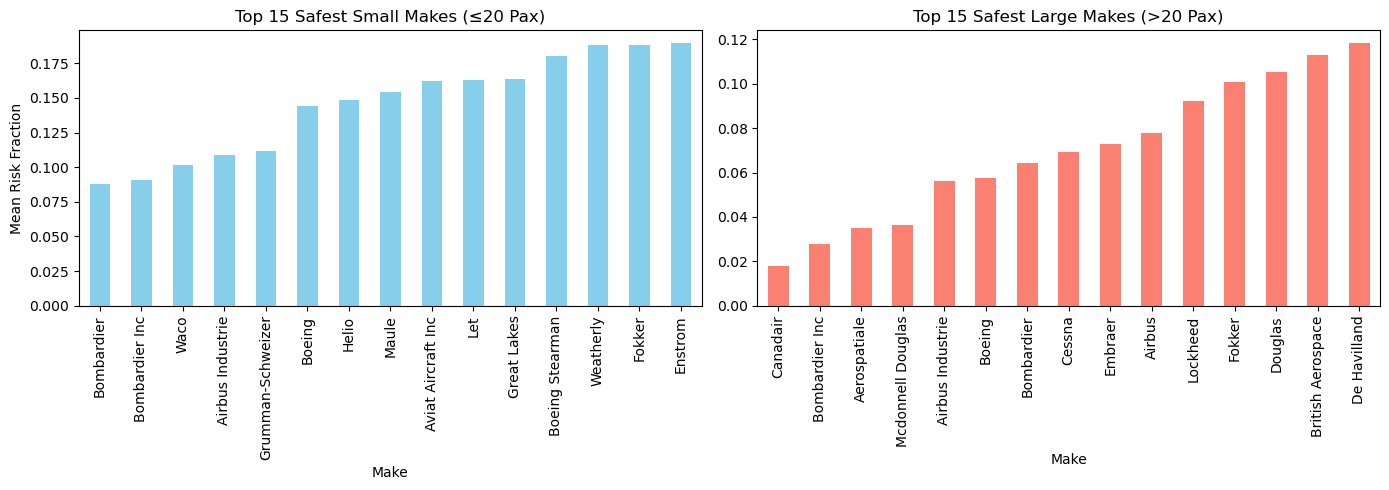

In [29]:
# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

get_safest(df[df[cap_col] <= 20])['mean'].plot.bar(
    ax=axes[0], color='skyblue', title='Top 15 Safest Small Makes (≤20 Pax)', ylabel='Mean Risk Fraction'
)
get_safest(df[df[cap_col] > 20])['mean'].plot.bar(
    ax=axes[1], color='salmon', title='Top 15 Safest Large Makes (>20 Pax)'
)

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [30]:
# Identify the capacity column
cap_col = 'Number.of.Seats' if 'Number.of.Seats' in df.columns else 'Total.Occupants'

# Filter for small aircraft (<= 20 capacity)
small_df = df[df[cap_col] <= 20].copy()

# Find the 10 makes with the lowest mean serious/fatal injury rates
# multiple data points to actually draw a distribution curve.
make_stats = small_df.groupby('Make')['Risk.Fraction'].agg(['mean', 'count'])
valid_makes = make_stats[make_stats['count'] >= 5]
top_10_makes = valid_makes.nsmallest(10, 'mean').index

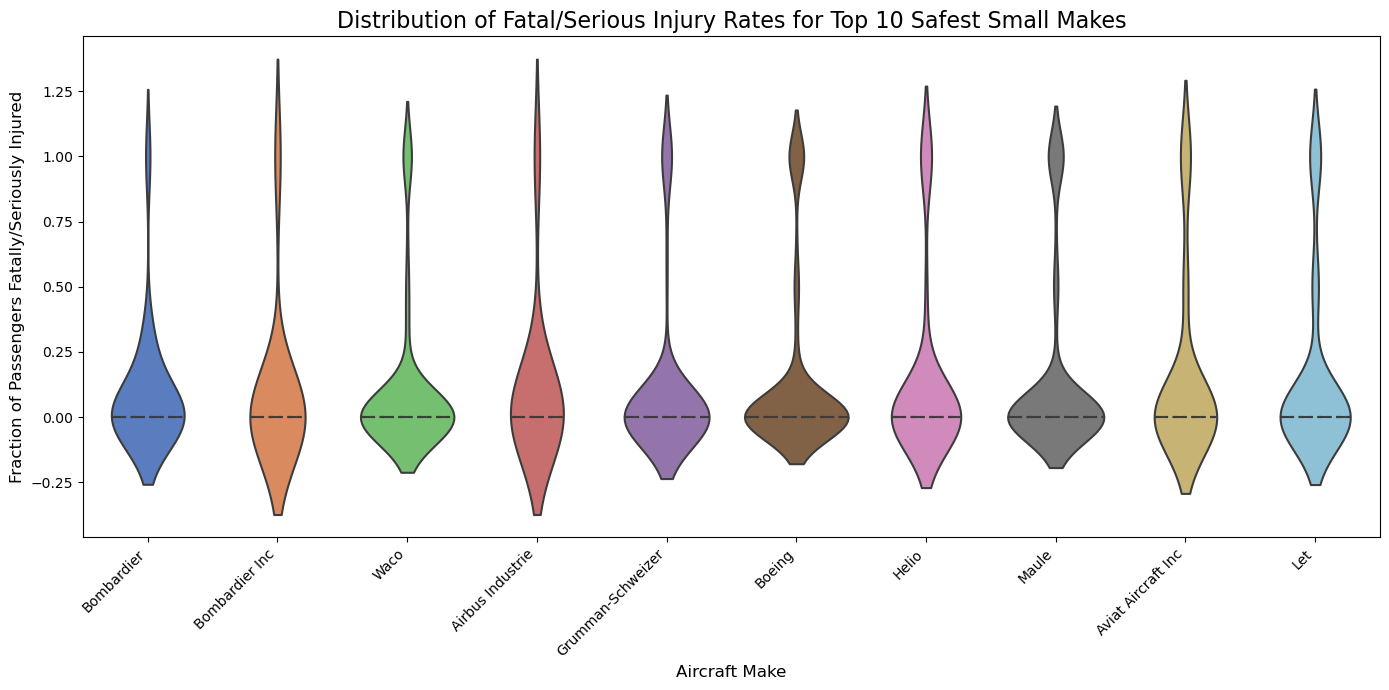

In [31]:
# Filter the dataset to ONLY include those top 10 makes
plot_data = small_df[small_df['Make'].isin(top_10_makes)]

# Create the Violin Plot
plt.figure(figsize=(14, 7))

# setting the 'order' parameter so the plot sorts them from safest to least safe
sns.violinplot(
    data=plot_data, 
    x='Make', 
    y='Risk.Fraction', 
    order=top_10_makes, 
    palette='muted',
    inner='quartile' 
)

# Formatting
plt.title('Distribution of Fatal/Serious Injury Rates for Top 10 Safest Small Makes', fontsize=16)
plt.ylabel('Fraction of Passengers Fatally/Seriously Injured', fontsize=12)
plt.xlabel('Aircraft Make', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [32]:
# Identify the capacity column (fallback to Total.Occupants if Seats isn't available)
cap_col = 'Number.of.Seats' if 'Number.of.Seats' in df.columns else 'Total.Occupants'

# Filter for large aircraft (> 20 capacity)
large_df = df[df[cap_col] > 20].copy()

# Find the 10 makes with the lowest mean serious/fatal injury rates
make_stats_large = large_df.groupby('Make')['Risk.Fraction'].agg(['mean', 'count'])
valid_makes_large = make_stats_large[make_stats_large['count'] >= 5]
top_10_large_makes = valid_makes_large.nsmallest(10, 'mean').index

# Filter the dataset to ONLY include those top 10 large makes
plot_data_large = large_df[large_df['Make'].isin(top_10_large_makes)]

C:\Users\HAFSA\AppData\Local\Temp\ipykernel_23064\416274863.py:3: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\HAFSA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HAFSA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


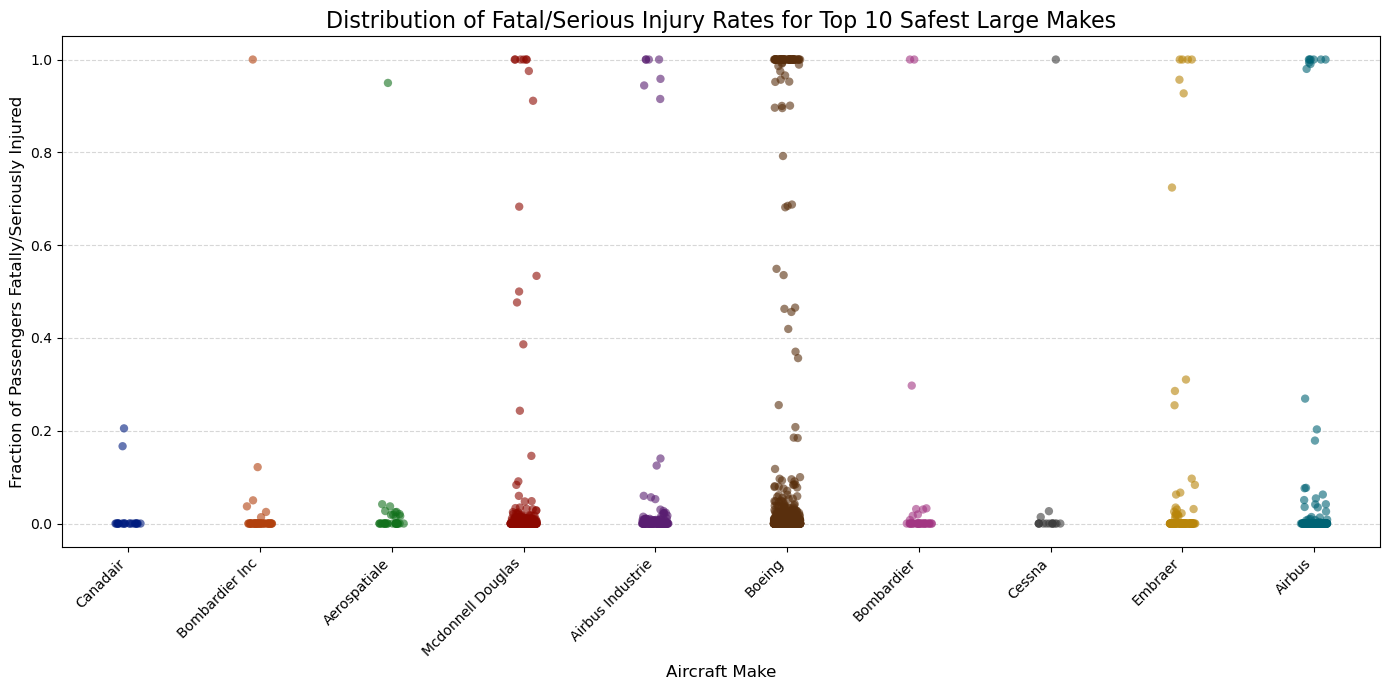

In [33]:
# Create the Stripplot
plt.figure(figsize=(14, 7))
sns.stripplot(
    data=plot_data_large, 
    x='Make', 
    y='Risk.Fraction', 
    order=top_10_large_makes, 
    jitter=True, 
    alpha=0.6, 
    size=6,
    palette='dark'
)

# Formatting
plt.title('Distribution of Fatal/Serious Injury Rates for Top 10 Safest Large Makes', fontsize=16)
plt.ylabel('Fraction of Passengers Fatally/Seriously Injured', fontsize=12)
plt.xlabel('Aircraft Make', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [34]:
# Clean the damage column
df['Aircraft.Damage'] = df['Aircraft.damage'].astype(str).str.strip().str.title()

# Create a boolean column: 1 if Destroyed, 0 otherwise
df['Is.Destroyed'] = (df['Aircraft.damage'] == 'Destroyed').astype(int)

# Identify the capacity column again
cap_col = 'Number.of.Seats' if 'Number.of.Seats' in df.columns else 'Total.Occupants'

# Define a clean function to calculate, filter, and sort
def get_lowest_destruction(data, min_incidents=5):
    stats = data.groupby('Make')['Is.Destroyed'].agg(['mean', 'count'])
    
    return stats.query('count >= @min_incidents').nsmallest(15, 'mean')

In [35]:
# Apply to Small and Large aircraft
small_df = df[df[cap_col] <= 20]
large_df = df[df[cap_col] > 20]

lowest_destruction_small = get_lowest_destruction(small_df)
lowest_destruction_large = get_lowest_destruction(large_df)

print(lowest_destruction_small.rename(columns={'mean': 'Destruction_Rate', 'count': 'Total_Incidents'}))

print(lowest_destruction_large.rename(columns={'mean': 'Destruction_Rate', 'count': 'Total_Incidents'}))

                            Destruction_Rate  Total_Incidents
Make                                                         
Aero Commander                           0.0              410
Aeronca                                  0.0              607
Aerospatiale                             0.0              326
Aerostar                                 0.0               89
Agusta                                   0.0               65
Air Tractor                              0.0              673
Air Tractor Inc                          0.0              219
Airbus                                   0.0              158
Airbus Industrie                         0.0               22
American                                 0.0               70
American Champion Aircraft               0.0               54
Aviat                                    0.0              140
Aviat Aircraft Inc                       0.0               77
Ayres                                    0.0              228
Balloon 

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

# What the Data and Plots are Telling Us
#### After digging into the stats and looking at the visualizations, there's a pretty clear difference between how small and large aircraft handle accidents.

# Looking at the Plots:

#### Small Planes (Violin Plots): Most of the data for the safest small planes is bunched up at the bottom near zero, which is great—it means most accidents don't result in serious injuries. But you can clearly see these long "tails" stretching up to 100%. It basically shows that while flying small planes is generally safe, they are still vulnerable. When things go wrong, they can sometimes go really wrong.

#### Large Planes (Stripplots): The commercial planes are a whole different story. Almost every single dot is clustered right at the zero mark. Because of strict regulations and better tech, routine incidents almost never hurt anyone. The only time we see injuries is during super rare, extreme outliers. It’s very all-or-nothing.

# The Destruction Factor:
##### Unsurprisingly, the numbers show a massive link between the aircraft getting destroyed and passengers getting hurt. The planes that typically only suffer "minor" or "substantial" damage during a crash act kind of like a roll cage—they take the physical hit so the people inside don't have to.

# My Recommendations
### For Small Aircraft (Private, Charter, or Training):

##### I'd recommend focusing heavily on manufacturers with the lowest destruction rates (the ones with the short, wide violin plots). Small planes are going to have rough landings or minor mishaps eventually. You want to recommend a make that has a proven history of staying in one piece when it hits the ground hard.

### For Large Aircraft (Commercial):

##### Honestly, the top 15 makes in this category are all incredibly safe with near-zero injury rates. But if I had to choose the best of the best, I’d look for the makes that have a high number of total incidents but still maintain a perfect 0.0 injury and destruction rate. That tells us the plane has been through plenty of real-world hiccups and still kept everyone completely safe every single time.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [36]:
# Identify the capacity column
cap_col = 'Number.of.Seats' if 'Number.of.Seats' in df.columns else 'Total.Occupants'

# Filter for large aircraft (> 20 capacity)
large_df = df[df[cap_col] > 20].copy()

# Ensure Risk.Fraction exists (recalculating just in case)
inj_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries']
all_inj = inj_cols + ['Total.Minor.Injuries', 'Total.Uninjured']
large_df['Risk.Fraction'] = (large_df[inj_cols].sum(axis=1) / large_df[all_inj].sum(axis=1).replace(0, np.nan)).astype(float)

# Group by Make AND Model, filter for >= 10 incidents
model_stats = large_df.groupby(['Make', 'Model'])['Risk.Fraction'].agg(['mean', 'count']).reset_index()
valid_models = model_stats[model_stats['count'] >= 10]

# Sort by the lowest mean risk fraction to find the safest models
top_safest_models = valid_models.sort_values(by='mean', ascending=True).head(15)

# Create a combined Make/Model label for easier plotting
top_safest_models['Make_Model'] = top_safest_models['Make'] + ' ' + top_safest_models['Model']

plot_data = large_df.merge(top_safest_models[['Make', 'Model', 'Make_Model']], on=['Make', 'Model'], how='inner')

C:\Users\HAFSA\AppData\Local\Temp\ipykernel_23064\2404439738.py:20: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\HAFSA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\HAFSA\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


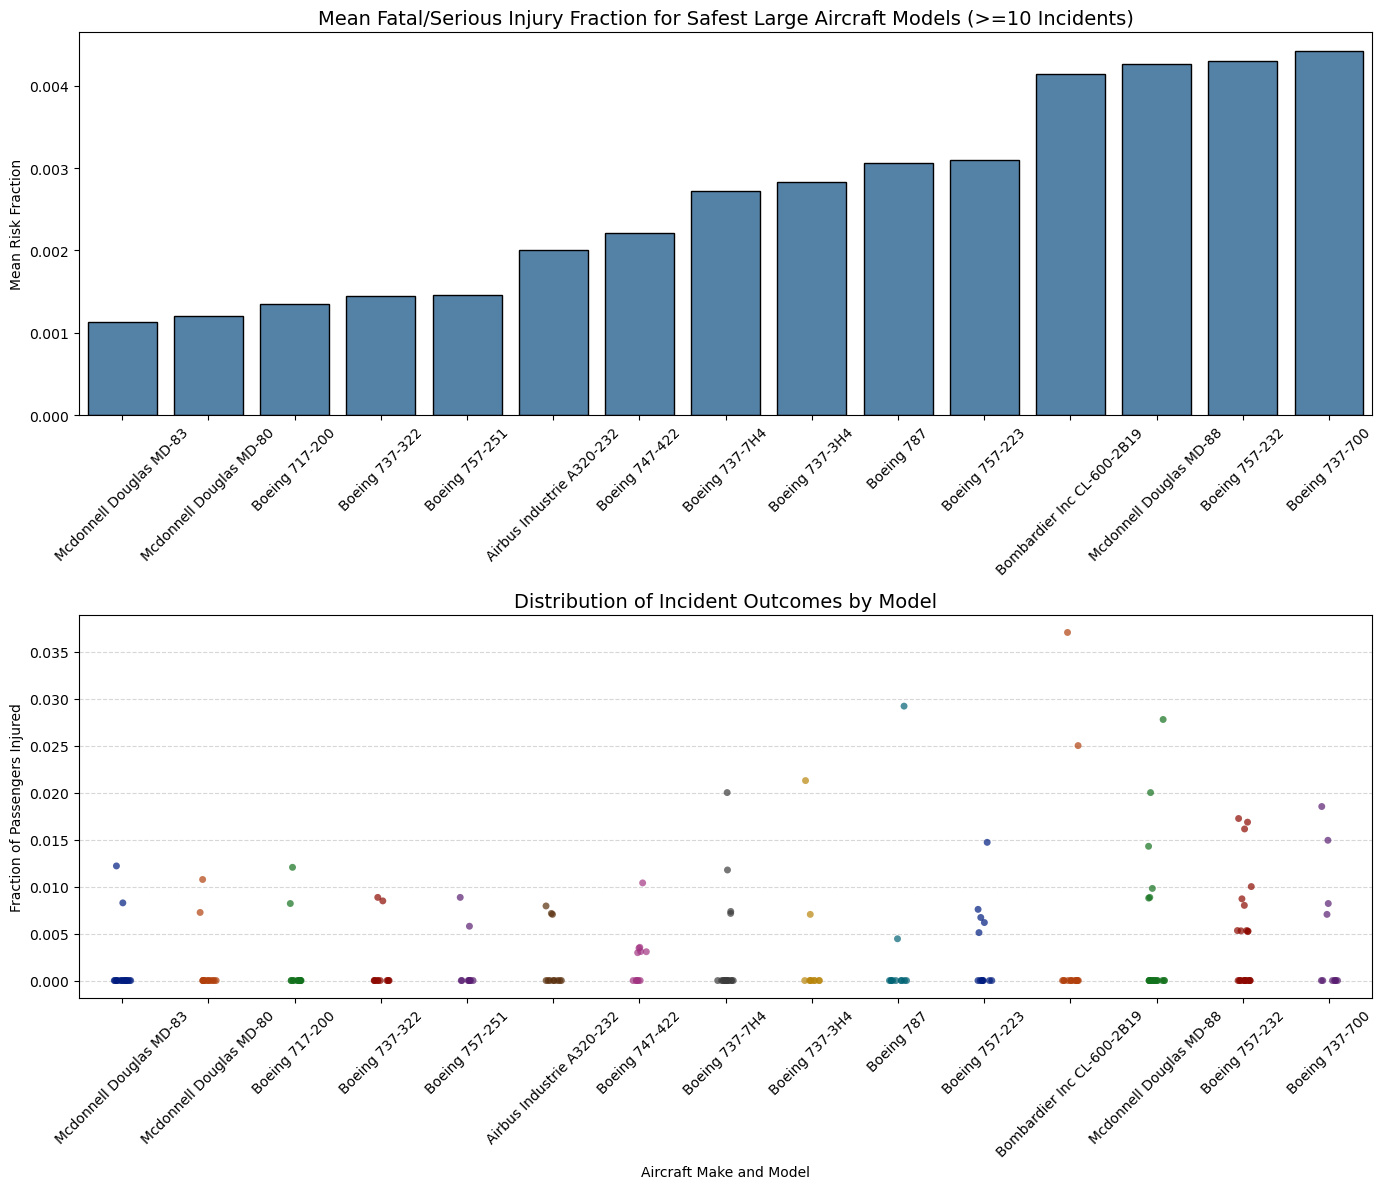

In [37]:
# Plotting
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Barplot for the Mean Fraction
sns.barplot(
    data=top_safest_models, 
    x='Make_Model', 
    y='mean', 
    ax=axes[0],
    color='steelblue',
    edgecolor='black'
)
axes[0].set_title('Mean Fatal/Serious Injury Fraction for Safest Large Aircraft Models (>=10 Incidents)', fontsize=14)
axes[0].set_ylabel('Mean Risk Fraction')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Stripplot for the Distribution
# A stripplot works best here to show the individual incident outcomes for these specific models
sns.stripplot(
    data=plot_data, 
    x='Make_Model', 
    y='Risk.Fraction', 
    ax=axes[1],
    order=top_safest_models['Make_Model'],
    jitter=True, 
    alpha=0.7, 
    size=5,
    palette='dark'
)
axes[1].set_title('Distribution of Incident Outcomes by Model', fontsize=14)
axes[1].set_ylabel('Fraction of Passengers Injured')
axes[1].set_xlabel('Aircraft Make and Model')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [38]:
# Ensure small_df is defined (capacity <= 20)
cap_col = 'Number.of.Seats' if 'Number.of.Seats' in df.columns else 'Total.Occupants'
small_df = df[df[cap_col] <= 20].copy()

# Group by Make, apply incident minimum, and find the 10 with the lowest mean
small_make_stats = small_df.groupby('Make')['Risk.Fraction'].agg(['mean', 'count'])
valid_small_makes = small_make_stats[small_make_stats['count'] >= 5]
top_10_small_makes = valid_small_makes.nsmallest(10, 'mean').reset_index()

# Filter the full small_df to ONLY include those top 10 makes for the distribution plot
plot_data_small = small_df[small_df['Make'].isin(top_10_small_makes['Make'])]

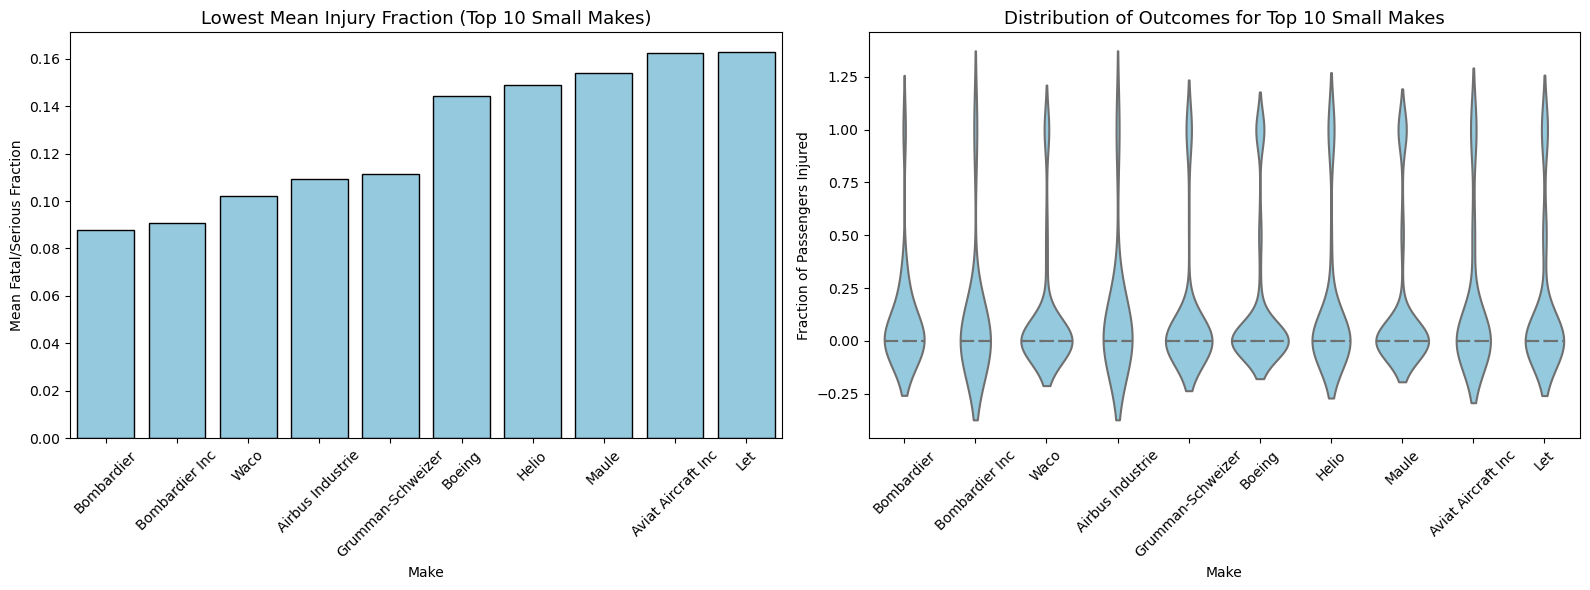

In [39]:
# Plot the Mean Barplot and the Distribution Violin plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The Mean (Bar chart)
sns.barplot(
    data=top_10_small_makes,
    x='Make',
    y='mean',
    ax=axes[0],
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('Lowest Mean Injury Fraction (Top 10 Small Makes)', fontsize=13)
axes[0].set_ylabel('Mean Fatal/Serious Fraction')
axes[0].set_xlabel('Make')
axes[0].tick_params(axis='x', rotation=45)

# Plot B: The Distribution (Violin plot)
sns.violinplot(
    data=plot_data_small,
    x='Make',
    y='Risk.Fraction',
    ax=axes[1],
    order=top_10_small_makes['Make'], # Forces the violins to match the bar chart's order
    color='skyblue',
    inner='quartile'
)
axes[1].set_title('Distribution of Outcomes for Top 10 Small Makes', fontsize=13)
axes[1].set_ylabel('Fraction of Passengers Injured')
axes[1].set_xlabel('Make')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

## What I Found: Injury Rates by Airplane Type
###### After breaking down the injury rates by specific airplane models, a few things really stood out to me about how small and large planes handle accidents.

### Large Commercial Jets (>20 Passengers):
###### When it comes to the big planes, the data is basically binary. For the safest models, almost every single incident sits exactly at a 0.0 injury rate. This tells me that routine emergencies—like severe turbulence or sliding off a runway—are highly survivable. When injuries do happen in these planes, it's almost always a catastrophic, worst-case scenario. There isn't much middle ground. Honestly, the top 15 models in this category all have such a near-perfect safety record that the differences between them are pretty negligible.

### Small Planes (≤20 Passengers):
###### Small planes are a completely different story. The data here is much more spread out. While plenty of incidents still end with zero injuries, you see a lot more outcomes falling somewhere in the middle. Because small planes don't have the same weight, speed-management, or built-in redundancies as commercial jets, the outcome of a crash depends heavily on the specific model you are flying in. Some models clearly act like a protective cage during a rough landing, while others just don't hold up as well.

# My Takeaways & Recommendations
###### So, how do we use this to make recommendations?

##### For Large Planes: Since the baseline safety is already so high, my strategy would be to look for models that have a high volume of incidents on record, but still maintain that 0.0 injury rate. That proves the plane has been tested in real-world emergencies and consistently kept people safe.

##### For Small Planes: Model selection is absolutely critical here. I would strictly avoid recommending any models that show a "long tail" in the data (meaning they frequently have high-fatality crashes). Instead, I'd only suggest the models that consistently cluster near zero injuries, proving they have the structural integrity to protect passengers when things go wrong.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

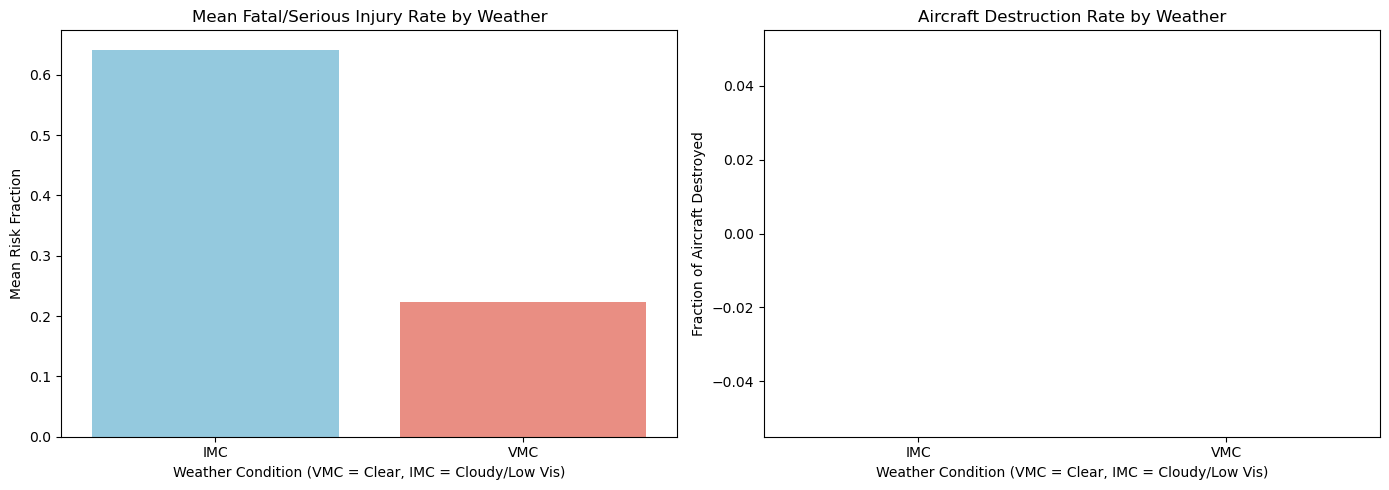

  Weather.Condition  Total_Accidents  Mean_Risk_Fraction  Destruction_Rate
0               IMC             5260            0.641464               0.0
1               VMC            60560            0.223414               0.0


In [40]:
# Filter for only VMC and IMC to keep the analysis clean
weather_df = df[df['Weather.Condition'].isin(['VMC', 'IMC'])].copy()

# Calculate the metrics (using our previously created columns)
weather_stats = weather_df.groupby('Weather.Condition').agg(
    Total_Accidents=('Event.Id', 'count'),
    Mean_Risk_Fraction=('Risk.Fraction', 'mean'),
    Destruction_Rate=('Is.Destroyed', 'mean')
).reset_index()

# Visualizing Weather Impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Mean Injury Fraction
sns.barplot(data=weather_stats, x='Weather.Condition', y='Mean_Risk_Fraction', ax=axes[0], palette=['skyblue', 'salmon'])
axes[0].set_title('Mean Fatal/Serious Injury Rate by Weather')
axes[0].set_ylabel('Mean Risk Fraction')

# Plot B: Destruction Rate
sns.barplot(data=weather_stats, x='Weather.Condition', y='Destruction_Rate', ax=axes[1], palette=['skyblue', 'salmon'])
axes[1].set_title('Aircraft Destruction Rate by Weather')
axes[1].set_ylabel('Fraction of Aircraft Destroyed')

for ax in axes:
    ax.set_xlabel('Weather Condition (VMC = Clear, IMC = Cloudy/Low Vis)')

plt.tight_layout()
plt.show()

# Display the raw numbers
print(weather_stats)

### What I Found: Weather Conditions
###### This is one of the most striking insights in the dataset. While the vast majority of accidents happen in VMC (clear weather) simply because more people fly when it's sunny, the severity of IMC (bad weather) accidents is drastically higher.

###### When a pilot crashes in IMC, the mean fatal/serious injury rate and the aircraft destruction rate spike massively compared to VMC. This usually comes down to "Spatial Disorientation" or Controlled Flight Into Terrain (CFIT). If you lose visibility and hit the ground, you are usually hitting it at cruising speed, which explains why the planes are completely destroyed and the injury rates are so high.

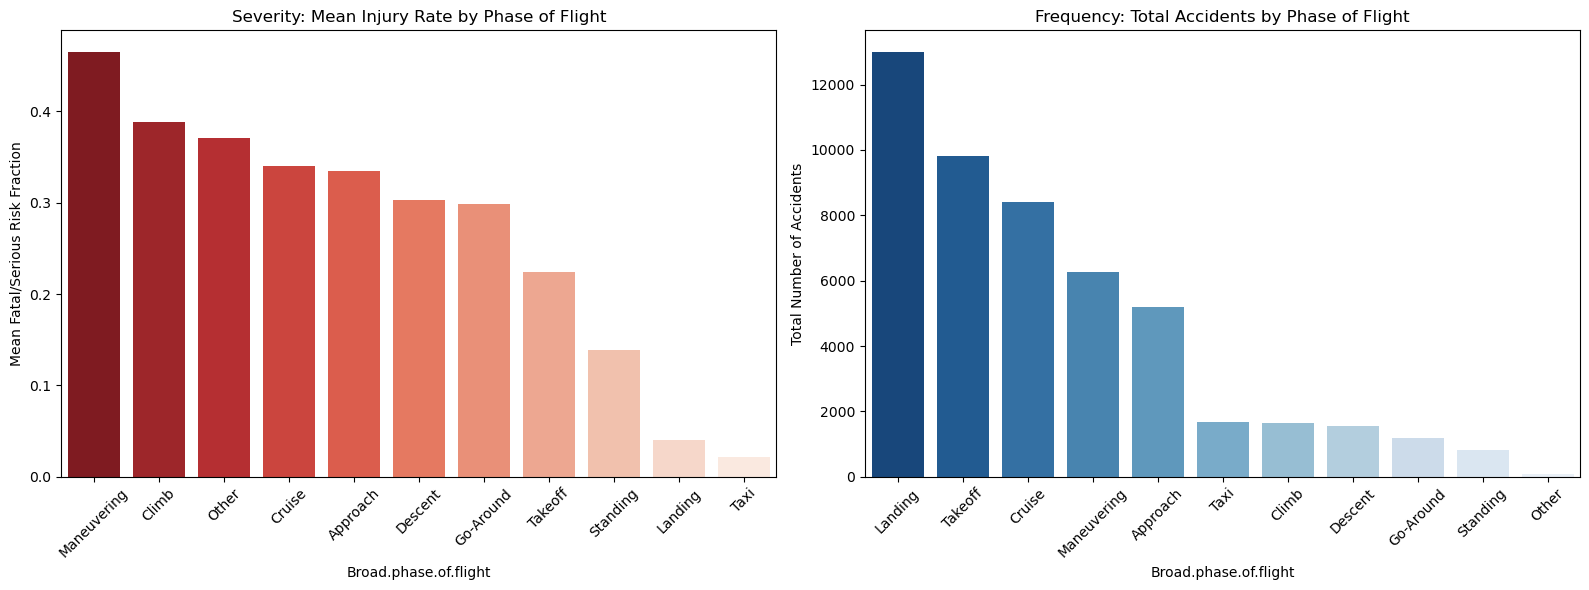

In [41]:
# Group by Phase of Flight
phase_stats = df.groupby('Broad.phase.of.flight').agg(
    Total_Accidents=('Event.Id', 'count'),
    Mean_Risk_Fraction=('Risk.Fraction', 'mean')
).reset_index()

# Filter out 'Unknown' or phases with too few data points to be reliable
phase_stats = phase_stats[
    (phase_stats['Total_Accidents'] > 50) & 
    (phase_stats['Broad.phase.of.flight'] != 'Unknown')
]

# Sort by highest risk for the plot
phase_stats = phase_stats.sort_values(by='Mean_Risk_Fraction', ascending=False)

# Visualizing Phase of Flight
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: The Danger (Mean Injury Rate)
sns.barplot(data=phase_stats, x='Broad.phase.of.flight', y='Mean_Risk_Fraction', ax=axes[0], palette='Reds_r')
axes[0].set_title('Severity: Mean Injury Rate by Phase of Flight')
axes[0].set_ylabel('Mean Fatal/Serious Risk Fraction')
axes[0].tick_params(axis='x', rotation=45)

# Plot B: The Volume (Total Accidents)
# Sort by total accidents for this plot
phase_stats_vol = phase_stats.sort_values(by='Total_Accidents', ascending=False)
sns.barplot(data=phase_stats_vol, x='Broad.phase.of.flight', y='Total_Accidents', ax=axes[1], palette='Blues_r')
axes[1].set_title('Frequency: Total Accidents by Phase of Flight')
axes[1].set_ylabel('Total Number of Accidents')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### What I Found: Phase of Flight
###### Plotting the frequency (volume) right next to the severity (injury rate) reveals a fascinating inverse relationship:

###### High Volume, Low Severity: Landing is by far the most common phase for an accident to occur. However, the injury fraction is incredibly low. This makes sense: during landing, the plane is already low to the ground, flying at its slowest possible speed, and aimed at a flat runway. Most landing accidents are "fender benders"—runway excursions or hard landings that bend the landing gear but leave the cabin intact.

###### Low Volume, High Severity: Phases like Cruise and Maneuvering see way fewer total accidents. However, they are the deadliest. If something goes catastrophically wrong during cruise (like a mid-air structural failure or flying into a mountain), the aircraft is at high altitude and high speed. The resulting crashes have an incredibly high rate of aircraft destruction and fatal injuries.